<a href="https://colab.research.google.com/github/VLCHS/FCNN_5_reactions/blob/main/FCNN_5_reactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Get Started

In [1]:
!pip install -q torch lightning comet_ml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 35.1 MB/s eta 0:00:00


In [2]:
import os
import comet_ml
import torch
import random
import math
import numpy as np
import pandas as pd
import torch.nn as nn
import lightning as L
import matplotlib.pyplot as plt

from torchmetrics import MetricCollection, MeanAbsoluteError, MeanSquaredError
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.optim.lr_scheduler import ReduceLROnPlateau

from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.loggers import CometLogger

from torch.utils.data import random_split
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.utils import resample

def set_random_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)
    L.seed_everything(seed)

set_random_seed(42)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


In [3]:
device = "gpu" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using gpu device


In [4]:
comet_ml.login()

Please paste your Comet API key from https://www.comet.com/api/my/settings/
(api key may not show as you type)
Comet API key: ··········


COMET INFO: Valid Comet API Key saved in /root/.comet.config (set COMET_CONFIG to change where it is saved).


In [5]:
exp = comet_ml.start(project_name="val_test_mae")
run_name = exp.name

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/chistiakova-vv19/val-test-mae/03cda3ac2dad4edab293e18f0c1a26a3



In [6]:
params_dict = {
    'feature_scaler': StandardScaler(),
    'label_scaler': MinMaxScaler(),
    'batch_size': 256,
    'net_architecture': [7, 60, 80, 100, 120, 140, 240, 340, 440, 640, 2000, 1040, 640, 340, 240, 140, 100, 80, 60, 20, 1],
    'activation_function': nn.ReLU,
    # 'loss_func': 'RMSELoss()',
    'optim_func': torch.optim.Adam,
    'max_epochs': 200,
    'es_min_delta': 0.00001,
    'es_patience': 150,
    'lr': 0.001,
    'lr_factor':0.5,
    'lr_patience': 5,
    'lr_cooldown': 20,
}

# Подготовка данных

In [7]:
from google.colab import files
uploaded = files.upload()

Saving clasdb_pi_0_p.txt to clasdb_pi_0_p.txt
Saving clasdb_pi_plus_n.txt to clasdb_pi_plus_n.txt


##$ \pi^{+} n$

In [8]:
# pi_plus_n 00001
df_pi_plus_n = pd.read_csv('/content/clasdb_pi_plus_n.txt', delimiter='\t', header=None)
df_pi_plus_n.columns = ['Ebeam', 'W', 'Q2', 'cos_theta', 'phi', 'dsigma_dOmega', 'error', 'id']
df_pi_plus_n.loc[8314:65670, 'Ebeam'] = 5.754 # peculiarity of this dataset.
df_pi_plus_n['phi'] = df_pi_plus_n.phi.apply(lambda x: math.radians(x))
df_pi_plus_n['cos_phi'] = df_pi_plus_n['phi'].apply(lambda x: math.cos(x))
df_pi_plus_n['sin_phi'] = df_pi_plus_n['phi'].apply(lambda x: math.sin(x))

df_pi_plus_n = df_pi_plus_n.iloc[df_pi_plus_n[['Ebeam', 'W', 'Q2', 'cos_theta', 'phi']].drop_duplicates().index]
df_pi_plus_n = df_pi_plus_n[df_pi_plus_n.dsigma_dOmega <= df_pi_plus_n.dsigma_dOmega.quantile(0.97)]
df_pi_plus_n = df_pi_plus_n[df_pi_plus_n['error'] <= df_pi_plus_n["error"].quantile(0.98)]

df_pi_plus_n = df_pi_plus_n.drop('id', axis=1)
df_pi_plus_n = df_pi_plus_n.reset_index(drop=True)

df_pi_plus_n['A'] = 1
# df_pi_plus_n['B'] = 0
# df_pi_plus_n['C'] = 0
# df_pi_plus_n['D'] = 0
# df_pi_plus_n['E'] = 1

df_pi_plus_n

,Ebeam,W,Q2,cos_theta,phi,dsigma_dOmega,error,cos_phi,sin_phi,A
0,1.515,1.11,0.3,0.92388,0.261799,3.1290,0.706242,0.965926,0.258819,1
1,1.515,1.11,0.3,0.92388,0.785398,2.6390,0.559253,0.707107,0.707107,1
2,1.515,1.11,0.3,0.92388,1.308997,3.5890,0.666589,0.258819,0.965926,1
3,1.515,1.11,0.3,0.92388,1.832596,4.8420,0.782739,-0.258819,0.965926,1
4,1.515,1.11,0.3,0.92388,4.974188,4.3960,0.742866,0.258819,-0.965926,1
...,...,...,...,...,...,...,...,...,...,...
88813,5.499,2.01,4.0,0.97500,3.730641,0.1012,0.043165,-0.831470,-0.555570,1
88814,5.499,2.01,4.0,0.97500,3.992441,0.1199,0.076638,-0.659346,-0.751840,1
88815,5.499,2.01,4.0,0.97500,4.646939,0.1578,0.095391,-0.065403,-0.997859,1
88816,5.499,2.01,4.0,0.97500,4.777839,0.2346,0.158557,0.065403,-0.997859,1


##$ \pi^{0} p$

In [9]:
# pi_0_p 00010
df_pi_0_p = pd.read_csv('/content/clasdb_pi_0_p.txt', delimiter='\t', header=None)
df_pi_0_p.columns = ['Ebeam', 'W', 'Q2', 'cos_theta', 'phi', 'dsigma_dOmega', 'error', 'id']
df_pi_0_p['phi'] = df_pi_0_p.phi.apply(lambda x: math.radians(x))
df_pi_0_p['cos_phi'] = df_pi_0_p['phi'].apply(lambda x: math.cos(x))
df_pi_0_p['sin_phi'] = df_pi_0_p['phi'].apply(lambda x: math.sin(x))
df_pi_0_p['Ebeam'] = df_pi_0_p['Ebeam'].round(decimals=2)
df_pi_0_p = df_pi_0_p.replace({"Ebeam": {2.45: 2.44, 1.65: 1.64}})

df_pi_0_p = df_pi_0_p.iloc[df_pi_0_p[['Ebeam', 'W', 'Q2', 'cos_theta', 'phi']].drop_duplicates().index]
df_pi_0_p = df_pi_0_p.drop(df_pi_0_p[df_pi_0_p['dsigma_dOmega'] == 0].index)
df_pi_0_p = df_pi_0_p.drop(df_pi_0_p[df_pi_0_p['dsigma_dOmega'] <= df_pi_0_p["error"]].index)
# df_pi_0_p = df_pi_0_p[df_pi_0_p['dsigma_dOmega'] <= df_pi_0_p["dsigma_dOmega"].quantile(0.97)]
# df_pi_0_p = df_pi_0_p[df_pi_0_p['error'] <= df_pi_0_p["error"].quantile(0.98)]

df_pi_0_p = df_pi_0_p.drop('id', axis=1)
df_pi_0_p = df_pi_0_p.reset_index(drop=True)


df_pi_0_p['A'] = 0
# df_pi_0_p['B'] = 0
# df_pi_0_p['C'] = 0
# df_pi_0_p['D'] = 1
# df_pi_0_p['E'] = 0

df_pi_0_p

,Ebeam,W,Q2,cos_theta,phi,dsigma_dOmega,error,cos_phi,sin_phi,A
0,1.64,1.1000,0.40,-0.9,2.356194,1.130000,0.909689,-0.707107,0.707107,0
1,1.64,1.1000,0.40,-0.9,4.974188,0.834000,0.830253,0.258819,-0.965926,0
2,1.64,1.1000,0.40,-0.7,0.785398,0.756000,0.682663,0.707107,0.707107,0
3,1.64,1.1000,0.40,-0.7,1.308997,2.340000,1.839669,0.258819,0.965926,0
4,1.64,1.1000,0.40,-0.7,1.832596,1.280000,0.702351,-0.258819,0.965926,0
...,...,...,...,...,...,...,...,...,...,...
72034,2.04,1.7875,0.65,0.9,5.105088,0.497479,0.107885,0.382683,-0.923880,0
72035,2.04,1.7875,0.65,0.9,5.366887,2.774690,2.426200,0.608761,-0.793353,0
72036,2.04,1.7875,0.65,0.9,5.628687,5.130680,4.529040,0.793353,-0.608761,0
72037,2.04,1.7875,0.65,0.9,5.890486,2.657480,2.404660,0.923880,-0.382683,0


##$K^{+} Σ^{0}$

In [ ]:
# K_plus_Sigma_0 00100
df_K_plus_Sigma_0 = pd.read_csv('/content/K_plus_Sigma_0_Carman_5.499GeV.txt', delimiter='\t')
df_K_plus_Sigma_0.columns = ['Measurement', 'Title', 'Year', 'W', 'Q2', 'cos_theta', 'phi', 'dsigma_dOmega', 'error']
df_K_plus_Sigma_0 = df_K_plus_Sigma_0.drop(['Measurement', 'Title', 'Year'], axis=1)
df_K_plus_Sigma_0['phi'] = df_K_plus_Sigma_0.phi.apply(lambda x: math.radians(x))
df_K_plus_Sigma_0['cos_phi'] = df_K_plus_Sigma_0['phi'].apply(lambda x: math.cos(x))
df_K_plus_Sigma_0['sin_phi'] = df_K_plus_Sigma_0['phi'].apply(lambda x: math.sin(x))
df_K_plus_Sigma_0['Ebeam'] = 5.499

df_K_plus_Sigma_0 = df_K_plus_Sigma_0.iloc[df_K_plus_Sigma_0[['Ebeam', 'W', 'Q2', 'cos_theta', 'phi']].drop_duplicates().index]
#df_K_plus_Sigma_0 = df_K_plus_Sigma_0.drop(df_K_plus_Sigma_0[df_K_plus_Sigma_0['dsigma_dOmega'] == 0].index)

df_K_plus_Sigma_0 = df_K_plus_Sigma_0.reset_index(drop=True)

df_K_plus_Sigma_0['A'] = 0
df_K_plus_Sigma_0['B'] = 0
df_K_plus_Sigma_0['C'] = 1
df_K_plus_Sigma_0['D'] = 0
df_K_plus_Sigma_0['E'] = 0

df_K_plus_Sigma_0

,W,Q2,cos_theta,phi,dsigma_dOmega,error,cos_phi,sin_phi,Ebeam,A,B,C,D,E
0,1.630,1.80,-0.775,-2.748894,0.000,0.000,-0.923880,-0.382683,5.499,0,0,1,0,0
1,1.630,1.80,-0.775,-1.963495,0.000,0.000,-0.382683,-0.923880,5.499,0,0,1,0,0
2,1.630,1.80,-0.775,-1.178097,0.000,0.000,0.382683,-0.923880,5.499,0,0,1,0,0
3,1.630,1.80,-0.775,-0.392699,0.000,0.000,0.923880,-0.382683,5.499,0,0,1,0,0
4,1.630,1.80,-0.775,0.392699,0.000,0.000,0.923880,0.382683,5.499,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3675,2.075,3.45,0.950,-0.392699,20.575,6.863,0.923880,-0.382683,5.499,0,0,1,0,0
3676,2.075,3.45,0.950,0.392699,30.536,8.371,0.923880,0.382683,5.499,0,0,1,0,0
3677,2.075,3.45,0.950,1.178097,23.212,7.384,0.382683,0.923880,5.499,0,0,1,0,0
3678,2.075,3.45,0.950,1.963495,21.316,6.246,-0.382683,0.923880,5.499,0,0,1,0,0


In [ ]:
proton_mass = 0.93827

In [ ]:
# K_plus_Sigma_0 00100
df_K_plus_Sigma_0_eps = pd.read_csv('/content/K_plus_Sigma_0_epsilon.txt', delimiter='\t')
df_K_plus_Sigma_0_eps.columns = ['Measurement', 'Title', 'Year', 'W', 'Q2', 'epsilon', 'cos_theta', 'phi', 'dsigma_dOmega', 'error']

df_K_plus_Sigma_0_eps['Nu'] = (df_K_plus_Sigma_0_eps['W'] ** 2 - proton_mass ** 2 + df_K_plus_Sigma_0_eps['Q2'] ** 2) / (2 * proton_mass)
df_K_plus_Sigma_0_eps['Ebeam'] = df_K_plus_Sigma_0_eps['Nu']/2 + ((1+df_K_plus_Sigma_0_eps['epsilon'])*(df_K_plus_Sigma_0_eps['Nu']**2+df_K_plus_Sigma_0_eps['Q2'])/(4*(1-df_K_plus_Sigma_0_eps['epsilon'])))**0.5
df_K_plus_Sigma_0_eps['Ebeam'] = df_K_plus_Sigma_0_eps['Ebeam'].round(decimals=2)

df_K_plus_Sigma_0_eps = df_K_plus_Sigma_0_eps.drop(['Measurement', 'Title', 'Year', 'Nu', 'epsilon'], axis=1)
df_K_plus_Sigma_0_eps['phi'] = df_K_plus_Sigma_0_eps.phi.apply(lambda x: math.radians(x))
df_K_plus_Sigma_0_eps['cos_phi'] = df_K_plus_Sigma_0_eps['phi'].apply(lambda x: math.cos(x))
df_K_plus_Sigma_0_eps['sin_phi'] = df_K_plus_Sigma_0_eps['phi'].apply(lambda x: math.sin(x))

df_K_plus_Sigma_0_eps = df_K_plus_Sigma_0_eps.iloc[df_K_plus_Sigma_0_eps[['Ebeam', 'W', 'Q2', 'cos_theta', 'phi']].drop_duplicates().index]
#df_K_plus_Sigma_0_eps = df_K_plus_Sigma_0_eps.drop(df_K_plus_Sigma_0_eps[df_K_plus_Sigma_0_eps['dsigma_dOmega'] == 0].index)

df_K_plus_Sigma_0_eps = df_K_plus_Sigma_0_eps.reset_index(drop=True)

df_K_plus_Sigma_0_eps['A'] = 0
df_K_plus_Sigma_0_eps['B'] = 0
df_K_plus_Sigma_0_eps['C'] = 1
df_K_plus_Sigma_0_eps['D'] = 0
df_K_plus_Sigma_0_eps['E'] = 0

df_K_plus_Sigma_0_eps

,W,Q2,cos_theta,phi,dsigma_dOmega,error,Ebeam,cos_phi,sin_phi,A,B,C,D,E
0,1.725,0.65,-0.60,-2.748894,4.736440,7.717344,2.39,-0.923880,-0.382683,0,0,1,0,0
1,1.725,0.65,-0.60,-1.963495,13.719921,10.588811,2.39,-0.382683,-0.923880,0,0,1,0,0
2,1.725,0.65,-0.60,-1.178097,9.737433,10.369698,2.39,0.382683,-0.923880,0,0,1,0,0
3,1.725,0.65,-0.60,-0.392699,37.902496,28.118521,2.39,0.923880,-0.382683,0,0,1,0,0
4,1.725,0.65,-0.60,0.392699,0.000000,0.000000,2.39,0.923880,0.382683,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3103,2.250,2.55,0.35,0.785398,0.000000,0.000000,6.25,0.707107,0.707107,0,0,1,0,0
3104,2.250,2.55,0.35,1.308997,12.082182,8.720255,6.25,0.258819,0.965926,0,0,1,0,0
3105,2.250,2.55,0.35,1.832596,11.256434,8.124320,6.25,-0.258819,0.965926,0,0,1,0,0
3106,2.250,2.55,0.35,2.356194,45.302162,20.257341,6.25,-0.707107,0.707107,0,0,1,0,0


##$K^{+} Λ$

In [ ]:
# df_K_plus_lambda 01000
df_K_plus_lambda = pd.read_csv('/content/K_plus_Lambda_Carman_5.499GeV.txt', delimiter='\t')
df_K_plus_lambda.columns = ['Measurement', 'Title', 'Year', 'W', 'Q2', 'cos_theta', 'phi', 'dsigma_dOmega', 'error']
df_K_plus_lambda = df_K_plus_lambda.drop(['Measurement', 'Title', 'Year'], axis=1)
df_K_plus_lambda['phi'] = df_K_plus_lambda.phi.apply(lambda x: math.radians(x))
df_K_plus_lambda['cos_phi'] = df_K_plus_lambda['phi'].apply(lambda x: math.cos(x))
df_K_plus_lambda['sin_phi'] = df_K_plus_lambda['phi'].apply(lambda x: math.sin(x))
df_K_plus_lambda['Ebeam'] = 5.499

df_K_plus_lambda = df_K_plus_lambda.iloc[df_K_plus_lambda[['Ebeam', 'W', 'Q2', 'cos_theta', 'phi']].drop_duplicates().index]
#df_K_plus_lambda = df_K_plus_lambda.drop(df_K_plus_lambda[df_K_plus_lambda['dsigma_dOmega'] == 0].index)

df_K_plus_lambda = df_K_plus_lambda.reset_index(drop=True)

df_K_plus_lambda['A'] = 0
df_K_plus_lambda['B'] = 1
df_K_plus_lambda['C'] = 0
df_K_plus_lambda['D'] = 0
df_K_plus_lambda['E'] = 0

df_K_plus_lambda

,W,Q2,cos_theta,phi,dsigma_dOmega,error,cos_phi,sin_phi,Ebeam,A,B,C,D,E
0,1.630,1.80,-0.775,-2.748894,68.896,9.857,-0.923880,-0.382683,5.499,0,1,0,0,0
1,1.630,1.80,-0.775,-1.963495,70.042,11.205,-0.382683,-0.923880,5.499,0,1,0,0,0
2,1.630,1.80,-0.775,-1.178097,92.990,16.987,0.382683,-0.923880,5.499,0,1,0,0,0
3,1.630,1.80,-0.775,-0.392699,89.746,15.395,0.923880,-0.382683,5.499,0,1,0,0,0
4,1.630,1.80,-0.775,0.392699,73.361,13.816,0.923880,0.382683,5.499,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3515,1.975,3.45,0.950,-0.392699,124.449,12.418,0.923880,-0.382683,5.499,0,1,0,0,0
3516,1.975,3.45,0.950,0.392699,133.054,12.852,0.923880,0.382683,5.499,0,1,0,0,0
3517,1.975,3.45,0.950,1.178097,113.484,12.090,0.382683,0.923880,5.499,0,1,0,0,0
3518,1.975,3.45,0.950,1.963495,105.505,11.535,-0.382683,0.923880,5.499,0,1,0,0,0


In [ ]:
# K_plus_lambda_eps 01000
df_K_plus_lambda_eps = pd.read_csv('/content/K_plus_Lambda_epsilon.txt', delimiter='\t')
df_K_plus_lambda_eps.columns = ['Measurement', 'Title', 'Year', 'W', 'Q2', 'epsilon', 'cos_theta', 'phi', 'dsigma_dOmega', 'error']

df_K_plus_lambda_eps['Nu'] = (df_K_plus_lambda_eps['W'] ** 2 - proton_mass ** 2 + df_K_plus_lambda_eps['Q2'] ** 2) / (2 * proton_mass)
df_K_plus_lambda_eps['Ebeam'] = df_K_plus_lambda_eps['Nu']/2 + ((1+df_K_plus_lambda_eps['epsilon'])*(df_K_plus_lambda_eps['Nu']**2+df_K_plus_lambda_eps['Q2'])/(4*(1-df_K_plus_lambda_eps['epsilon'])))**0.5
df_K_plus_lambda_eps['Ebeam'] = df_K_plus_lambda_eps['Ebeam'].round(decimals=2)

df_K_plus_lambda_eps = df_K_plus_lambda_eps.drop(['Measurement', 'Title', 'Year', 'Nu', 'epsilon'], axis=1)
df_K_plus_lambda_eps['phi'] = df_K_plus_lambda_eps.phi.apply(lambda x: math.radians(x))
df_K_plus_lambda_eps['cos_phi'] = df_K_plus_lambda_eps['phi'].apply(lambda x: math.cos(x))
df_K_plus_lambda_eps['sin_phi'] = df_K_plus_lambda_eps['phi'].apply(lambda x: math.sin(x))

df_K_plus_lambda_eps = df_K_plus_lambda_eps.iloc[df_K_plus_lambda_eps[['Ebeam', 'W', 'Q2', 'cos_theta', 'phi']].drop_duplicates().index]
#df_K_plus_lambda_eps = df_K_plus_lambda_eps.drop(df_K_plus_lambda_eps[df_K_plus_lambda_eps['dsigma_dOmega'] == 0].index)

df_K_plus_lambda_eps = df_K_plus_lambda_eps.reset_index(drop=True)

df_K_plus_lambda_eps['A'] = 0
df_K_plus_lambda_eps['B'] = 1
df_K_plus_lambda_eps['C'] = 0
df_K_plus_lambda_eps['D'] = 0
df_K_plus_lambda_eps['E'] = 0

df_K_plus_lambda_eps

,W,Q2,cos_theta,phi,dsigma_dOmega,error,Ebeam,cos_phi,sin_phi,A,B,C,D,E
0,1.65,0.65,-0.6,-2.748894,87.297874,10.404321,2.38,-0.923880,-0.382683,0,1,0,0,0
1,1.65,0.65,-0.6,-1.963495,78.333641,12.237539,2.38,-0.382683,-0.923880,0,1,0,0,0
2,1.65,0.65,-0.6,-1.178097,79.861671,13.427073,2.38,0.382683,-0.923880,0,1,0,0,0
3,1.65,0.65,-0.6,-0.392699,65.534607,30.847410,2.38,0.923880,-0.382683,0,1,0,0,0
4,1.65,0.65,-0.6,0.392699,98.443283,32.122162,2.38,0.923880,0.382683,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3263,2.25,2.55,0.9,0.785398,0.000000,0.000000,6.25,0.707107,0.707107,0,1,0,0,0
3264,2.25,2.55,0.9,1.308997,96.047852,120.059898,6.25,0.258819,0.965926,0,1,0,0,0
3265,2.25,2.55,0.9,1.832596,93.432312,67.429108,6.25,-0.258819,0.965926,0,1,0,0,0
3266,2.25,2.55,0.9,2.356194,71.595734,40.023407,6.25,-0.707107,0.707107,0,1,0,0,0


##$η p$

In [ ]:
# eta_p 10000
df_eta_p1 = pd.read_csv('/content/eta_p_6cols.txt', delimiter='\t')
df_eta_p1.columns = ['Measurement', 'Title', 'Year', 'W', 'Q2', 'cos_theta', 'phi', 'dsigma_dOmega', 'error']

df_eta_p2 = pd.read_csv('/content/eta_p_7cols.txt', delimiter='\t')
df_eta_p2.columns = ['Measurement', 'Title', 'Year', 'W', 'Q2', 'cos_theta', 'phi', 'dsigma_dOmega', 'error', 'Systematic error']
df_eta_p2 = df_eta_p2.drop(['Systematic error'], axis=1)

df_eta_p = pd.concat([df_eta_p1, df_eta_p2], ignore_index=True)

df_eta_p['Ebeam'] = df_eta_p['Measurement'].map({
    "Measurement E102M1": 1.515,
    "Measurement E102M2": 1.515,
    "Measurement E102M3": 1.515,
    "Measurement E102M4": 1.515,
    "Measurement E102M5": 1.515,
    "Measurement E102M6": 1.515,

    "Measurement E102M7": 2.567,
    "Measurement E102M8": 2.567,
    "Measurement E102M9": 2.567,
    "Measurement E102M10": 2.567,
    "Measurement E102M11": 2.567,
    "Measurement E102M12": 2.567,
    "Measurement E102M13": 2.567,
    "Measurement E102M14": 2.567,
    "Measurement E102M15": 2.567,
    "Measurement E102M16": 2.567,
    "Measurement E102M17": 2.567,
    "Measurement E102M18": 2.567,
    "Measurement E102M19": 2.567,
    "Measurement E102M20": 2.567,
    "Measurement E102M21": 2.567,
    "Measurement E102M22": 2.567,
    "Measurement E102M23": 2.567,
    "Measurement E102M24": 2.567,
    "Measurement E102M25": 2.567,
    "Measurement E102M26": 2.567,
    "Measurement E102M27": 2.567,
    "Measurement E102M28": 2.567,
    "Measurement E102M29": 2.567,
    "Measurement E102M30": 2.567,
    "Measurement E102M31": 2.567,
    "Measurement E102M32": 2.567,
    "Measurement E102M33": 2.567,
    "Measurement E102M34": 2.567,
    "Measurement E102M35": 2.567,

    "Measurement E102M36": 4.056,
    "Measurement E102M37": 4.056,
    "Measurement E102M38": 4.056,
    "Measurement E102M39": 4.056,
    "Measurement E102M40": 4.056,
    "Measurement E102M41": 4.056,
    "Measurement E102M42": 4.056,
    "Measurement E102M43": 4.056,
    "Measurement E102M44": 4.056,
    "Measurement E102M45": 4.056,
    "Measurement E102M46": 4.056,
    "Measurement E102M47": 4.056,
    "Measurement E102M48": 4.056,
    "Measurement E102M49": 4.056,
    "Measurement E102M50": 4.056,
    "Measurement E102M51": 4.056,
    "Measurement E102M52": 4.056,
    "Measurement E102M53": 4.056,
    "Measurement E102M54": 4.056,
    "Measurement E102M55": 4.056,
    "Measurement E102M56": 4.056,
    "Measurement E102M57": 4.056,
    "Measurement E102M58": 4.056,
    "Measurement E102M59": 4.056,
    "Measurement E102M60": 4.056,
    "Measurement E102M61": 4.056,
    "Measurement E102M62": 4.056,
    "Measurement E102M63": 4.056,
    "Measurement E102M64": 4.056,
    "Measurement E102M65": 4.056,
    "Measurement E102M66": 4.056,
    "Measurement E102M67": 4.056,
    "Measurement E102M68": 4.056,
    "Measurement E102M69": 4.056,
    "Measurement E102M70": 4.056,
    "Measurement E102M71": 4.056,
    "Measurement E102M72": 4.056,
    "Measurement E102M73": 4.056,
    "Measurement E102M74": 4.056,
    "Measurement E102M75": 4.056,
    "Measurement E102M76": 4.056,
    "Measurement E102M77": 4.056,
    "Measurement E102M78": 4.056,
    "Measurement E102M79": 4.056,
    "Measurement E102M80": 4.056,
    "Measurement E102M81": 4.056,
    "Measurement E102M82": 4.056,
    "Measurement E102M83": 4.056,
})

df_eta_p

,Measurement,Title,Year,W,Q2,cos_theta,phi,dsigma_dOmega,error,Ebeam
0,Measurement E102M7,E-89-039,2007,1.50,0.8,-0.9,15,0.678,0.070,2.567
1,Measurement E102M7,E-89-039,2007,1.50,0.8,-0.7,15,0.620,0.066,2.567
2,Measurement E102M7,E-89-039,2007,1.50,0.8,-0.5,15,0.867,0.076,2.567
3,Measurement E102M7,E-89-039,2007,1.50,0.8,-0.3,15,0.768,0.069,2.567
4,Measurement E102M7,E-89-039,2007,1.50,0.8,-0.1,15,0.775,0.070,2.567
...,...,...,...,...,...,...,...,...,...,...
3181,Measurement E102M83,E-89-039,2007,1.92,2.5,-0.4,135,0.015,0.033,4.056
3182,Measurement E102M83,E-89-039,2007,1.92,2.5,0.0,135,0.207,0.442,4.056
3183,Measurement E102M83,E-89-039,2007,1.92,2.5,0.4,135,0.011,0.017,4.056
3184,Measurement E102M83,E-89-039,2007,1.92,2.5,0.8,135,0.016,0.036,4.056


In [ ]:
df_eta_p = df_eta_p.drop(['Measurement', 'Title', 'Year'], axis=1)

df_eta_p['phi'] = df_eta_p.phi.apply(lambda x: math.radians(x))
df_eta_p['cos_phi'] = df_eta_p['phi'].apply(lambda x: math.cos(x))
df_eta_p['sin_phi'] = df_eta_p['phi'].apply(lambda x: math.sin(x))

df_eta_p = df_eta_p.iloc[df_eta_p[['Ebeam', 'W', 'Q2', 'cos_theta', 'phi']].drop_duplicates().index]
#df_eta_p = df_eta_p.drop(df_eta_p[df_eta_p['dsigma_dOmega'] == 0].index)

df_eta_p = df_eta_p.reset_index(drop=True)

df_eta_p['A'] = 1
df_eta_p['B'] = 0
df_eta_p['C'] = 0
df_eta_p['D'] = 0
df_eta_p['E'] = 0

df_eta_p

,W,Q2,cos_theta,phi,dsigma_dOmega,error,Ebeam,cos_phi,sin_phi,A,B,C,D,E
0,1.50,0.8,-0.9,0.261799,0.678,0.070,2.567,0.965926,0.258819,1,0,0,0,0
1,1.50,0.8,-0.7,0.261799,0.620,0.066,2.567,0.965926,0.258819,1,0,0,0,0
2,1.50,0.8,-0.5,0.261799,0.867,0.076,2.567,0.965926,0.258819,1,0,0,0,0
3,1.50,0.8,-0.3,0.261799,0.768,0.069,2.567,0.965926,0.258819,1,0,0,0,0
4,1.50,0.8,-0.1,0.261799,0.775,0.070,2.567,0.965926,0.258819,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3181,1.92,2.5,-0.4,2.356194,0.015,0.033,4.056,-0.707107,0.707107,1,0,0,0,0
3182,1.92,2.5,0.0,2.356194,0.207,0.442,4.056,-0.707107,0.707107,1,0,0,0,0
3183,1.92,2.5,0.4,2.356194,0.011,0.017,4.056,-0.707107,0.707107,1,0,0,0,0
3184,1.92,2.5,0.8,2.356194,0.016,0.036,4.056,-0.707107,0.707107,1,0,0,0,0


## EDA

In [ ]:
reactions_dict = {
    "1": "\u03B3 p \u27F6 \u03C0\u207A n",
    "2": "\u03B3 p \u27F6 \u03C0\u2070 p",
    "3": "\u03B3 p \u27F6 K\u207A \u03A3\u2070",
    "4": "\u03B3 p \u27F6 K\u207A \u039B",
    "5": "\u03B3 p \u27F6 \u03B7 p"
}

for key, value in reactions_dict.items():
  print("{0}: {1}".format(key,value))

n = input("Введите номер реакции: ")
reaction = reactions_dict.get(n)
print(f"Выбранная реакция: {reaction}")

1: γ p ⟶ π⁺ n
2: γ p ⟶ π⁰ p
3: γ p ⟶ K⁺ Σ⁰
4: γ p ⟶ K⁺ Λ
5: γ p ⟶ η p
Введите номер реакции: 5
Выбранная реакция: γ p ⟶ η p


Text(0, 0.5, 'Q², GeV²')

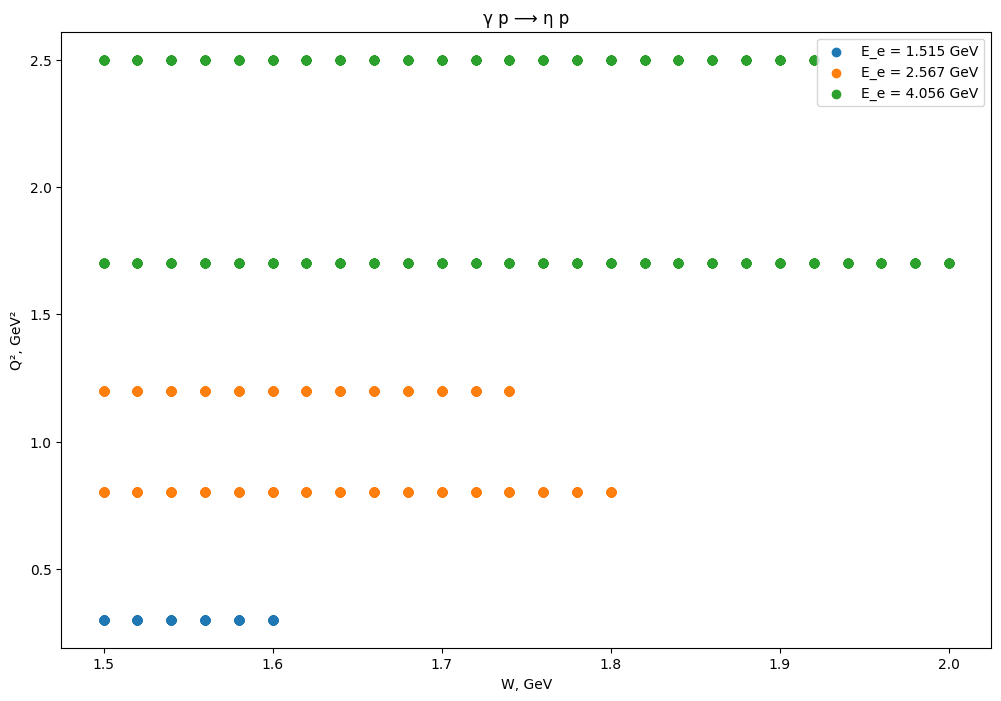

In [ ]:
df_dict = {
    "1": df_pi_plus_n,
    "2": df_pi_0_p,
    "3": pd.concat([df_K_plus_Sigma_0, df_K_plus_Sigma_0_eps], ignore_index=True),
    "4": pd.concat([df_K_plus_lambda, df_K_plus_lambda_eps], ignore_index=True),
    "5": df_eta_p
}

df_eda = df_dict.get(n)
energies = df_eda.Ebeam.unique()

plt.figure(figsize=(12, 8))
for energy in (sorted(energies)):
    plt.scatter(df_eda[df_eda.Ebeam==energy].W, df_eda[df_eda.Ebeam==energy].Q2, label=f"E_e = {energy} GeV")

plt.legend()
plt.title(reaction)
plt.xlabel('W, GeV')
plt.ylabel('Q\u00B2, GeV\u00B2')

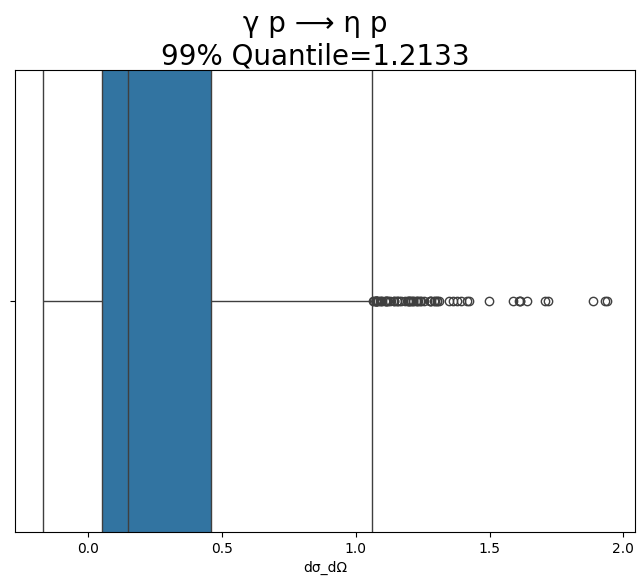

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x=df_eda['dsigma_dOmega'], width=4)
Q = df_eda["dsigma_dOmega"].quantile(0.99)
plt.suptitle("{}\n99% Quantile={}".format(reaction, f'{Q:.4f}'), fontsize=20)
plt.xlabel("d\u03C3_d\u03A9")
plt.show()

# Подготовка данных для нейронной сети

In [10]:
df = pd.concat([df_pi_plus_n, df_pi_0_p], ignore_index=True) #df_K_plus_Sigma_0, df_K_plus_Sigma_0_eps, df_K_plus_lambda, df_K_plus_lambda_eps, df_eta_p], ignore_index=True)
df

,Ebeam,W,Q2,cos_theta,phi,dsigma_dOmega,error,cos_phi,sin_phi,A
0,1.515,1.1100,0.30,0.92388,0.261799,3.129000,0.706242,0.965926,0.258819,1
1,1.515,1.1100,0.30,0.92388,0.785398,2.639000,0.559253,0.707107,0.707107,1
2,1.515,1.1100,0.30,0.92388,1.308997,3.589000,0.666589,0.258819,0.965926,1
3,1.515,1.1100,0.30,0.92388,1.832596,4.842000,0.782739,-0.258819,0.965926,1
4,1.515,1.1100,0.30,0.92388,4.974188,4.396000,0.742866,0.258819,-0.965926,1
...,...,...,...,...,...,...,...,...,...,...
160852,2.040,1.7875,0.65,0.90000,5.105088,0.497479,0.107885,0.382683,-0.923880,0
160853,2.040,1.7875,0.65,0.90000,5.366887,2.774690,2.426200,0.608761,-0.793353,0
160854,2.040,1.7875,0.65,0.90000,5.628687,5.130680,4.529040,0.793353,-0.608761,0
160855,2.040,1.7875,0.65,0.90000,5.890486,2.657480,2.404660,0.923880,-0.382683,0


In [11]:
df = df.drop(df[df['dsigma_dOmega'] == 0].index)
df = df.reset_index(drop=True)
df

,Ebeam,W,Q2,cos_theta,phi,dsigma_dOmega,error,cos_phi,sin_phi,A
0,1.515,1.1100,0.30,0.92388,0.261799,3.129000,0.706242,0.965926,0.258819,1
1,1.515,1.1100,0.30,0.92388,0.785398,2.639000,0.559253,0.707107,0.707107,1
2,1.515,1.1100,0.30,0.92388,1.308997,3.589000,0.666589,0.258819,0.965926,1
3,1.515,1.1100,0.30,0.92388,1.832596,4.842000,0.782739,-0.258819,0.965926,1
4,1.515,1.1100,0.30,0.92388,4.974188,4.396000,0.742866,0.258819,-0.965926,1
...,...,...,...,...,...,...,...,...,...,...
160852,2.040,1.7875,0.65,0.90000,5.105088,0.497479,0.107885,0.382683,-0.923880,0
160853,2.040,1.7875,0.65,0.90000,5.366887,2.774690,2.426200,0.608761,-0.793353,0
160854,2.040,1.7875,0.65,0.90000,5.628687,5.130680,4.529040,0.793353,-0.608761,0
160855,2.040,1.7875,0.65,0.90000,5.890486,2.657480,2.404660,0.923880,-0.382683,0


In [12]:
feature_columns = ["Ebeam", "W",	"Q2",	"cos_theta", "cos_phi", "sin_phi", "A"]
feature_data = df[feature_columns]
label_data = df['dsigma_dOmega']


#TRAIN TEST SPLIT
X_train, X_residual, y_train, y_residual = train_test_split(feature_data,
                                                            label_data,
                                                            test_size=0.2,
                                                            random_state=42)

X_test, X_val, y_test, y_val = train_test_split(X_residual,
                                                y_residual,
                                                test_size=0.5,
                                                random_state=42)


scaler_feature = params_dict.get('feature_scaler')
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

#scale feature_data
columns_to_scale = list(X_train.columns)
X_train[columns_to_scale] = pd.DataFrame(scaler_feature.fit_transform(X_train[columns_to_scale]))
X_val[columns_to_scale] = pd.DataFrame(scaler_feature.transform(X_val[columns_to_scale]))
X_test[columns_to_scale] = pd.DataFrame(scaler_feature.transform(X_test[columns_to_scale]))

#scale label_data
scaler_target = params_dict.get('label_scaler')
y_train = pd.Series(scaler_target.fit_transform(y_train.to_frame())[:,0])
y_val = pd.Series(scaler_target.transform(y_val.to_frame())[:,0])
y_test = pd.Series(scaler_target.transform(y_test.to_frame())[:,0])

X_train = torch.tensor(X_train.values, dtype=torch.float32)
X_test = torch.tensor(X_test.values, dtype=torch.float32)
X_val = torch.tensor(X_val.values, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)

train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)
test_data = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_data, batch_size=params_dict.get('batch_size'), shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=params_dict.get('batch_size'), shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=params_dict.get('batch_size'), shuffle=False)

# Создание модели

In [13]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.net_architecture = params_dict.get('net_architecture')
        self.activation_function = params_dict.get('activation_function')

        self.network = nn.Sequential()
        for i in range(1,len(self.net_architecture)):
            self.network.append(nn.Linear(self.net_architecture[i-1], self.net_architecture[i]))
            if i!=len(self.net_architecture)-1:
                self.network.append(self.activation_function())

            else:
                pass

    def forward(self, x):
        return self.network(x)

In [14]:
model = NeuralNetwork()

# Обучение

In [15]:
class Pipeline(L.LightningModule):
    def __init__(self, model, params, scaler_target=None):
        super().__init__()

        self.model = model
        self.params = params
        self.criterion = torch.nn.MSELoss()
        self.optimizer = self.params.get('optim_func')
        self.scaler_target = scaler_target

        self.metrics = MetricCollection([
            MeanAbsoluteError(),
            MeanSquaredError(),
            #R2Score()
        ])

        self.save_hyperparameters(ignore=['model', 'scaler_target'])

        self.train_metrics = self.metrics.clone(postfix='/train')
        self.val_metrics = self.metrics.clone(postfix='/val')
        self.test_metrics = self.metrics.clone(postfix='/test')

    def configure_optimizers(self):
        optimizer = self.optimizer(self.parameters(), lr=self.params.get('lr'))

        lr_optim = ReduceLROnPlateau(optimizer = optimizer,
                                     mode = 'min',
                                     factor = self.params.get('lr_factor'),
                                     patience = self.params.get('lr_patience'),
                                     cooldown=self.params.get('lr_cooldown'),
                                     threshold=0.01
                                     )
        return {"optimizer": optimizer,
                "lr_scheduler": {
                    "scheduler": lr_optim,
                    "interval": "epoch",
                    "monitor": "val_loss",
                    "frequency": 2,
                    "name": 'lr_scheduler_monitoring'
                    },
                }

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self.model(x)
        loss = torch.sqrt(self.criterion(out.reshape(-1), y))


        if self.scaler_target is not None:

            out_real = out.detach().cpu().numpy().reshape(-1, 1)
            y_real = y.detach().cpu().numpy().reshape(-1, 1)
            out_real = self.scaler_target.inverse_transform(out_real)
            y_real = self.scaler_target.inverse_transform(y_real)
            out_real = torch.from_numpy(out_real).flatten().to(self.device)
            y_real = torch.from_numpy(y_real).flatten().to(self.device)

            self.train_metrics.update(out_real.reshape(-1), y_real)

        else:
            self.train_metrics.update(out.reshape(-1), y)

        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss


    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self.model(x)
        loss = torch.sqrt(self.criterion(out.reshape(-1), y))

        if self.scaler_target is not None:

            out_real = out.detach().cpu().numpy().reshape(-1, 1)
            y_real = y.detach().cpu().numpy().reshape(-1, 1)
            out_real = self.scaler_target.inverse_transform(out_real)
            y_real = self.scaler_target.inverse_transform(y_real)
            out_real = torch.from_numpy(out_real).flatten().to(self.device)
            y_real = torch.from_numpy(y_real).flatten().to(self.device)

            self.val_metrics.update(out_real.reshape(-1), y_real)

        else:
            self.val_metrics.update(out.reshape(-1), y)

        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)


    def on_validation_epoch_end(self):
        self.log_dict(self.val_metrics.compute(), prog_bar=True)
        self.val_metrics.reset()

    def on_train_epoch_end(self):
        self.log_dict(self.train_metrics.compute(),  prog_bar=True)
        self.train_metrics.reset()

    def test_step(self, batch, batch_idx):
        x, y = batch
        out = self.model(x)

        if self.scaler_target is not None:

            out_real = out.detach().cpu().numpy().reshape(-1, 1)
            y_real = y.detach().cpu().numpy().reshape(-1, 1)
            out_real = self.scaler_target.inverse_transform(out_real)
            y_real = self.scaler_target.inverse_transform(y_real)
            out_real = torch.from_numpy(out_real).flatten().to(self.device)
            y_real = torch.from_numpy(y_real).flatten().to(self.device)

            self.test_metrics.update(out_real.reshape(-1), y_real)
            self.test_labels.append(y_real.cpu())
            self.test_predictions.append(out_real.cpu())

        else:
            self.test_metrics.update(out.reshape(-1), y)
            self.test_labels.append(y.cpu())
            self.test_predictions.append(out.cpu())


    def on_test_start(self):
        self.test_labels = []
        self.test_predictions = []

    def on_test_epoch_end(self):
        self.log_dict(self.test_metrics.compute())
        self.test_metrics.reset()

        # all_labels = torch.cat(self.test_labels)
        # all_predictions = torch.cat(self.test_predictions)

        # self.results_df = pd.DataFrame({
        #     'true_label': all_labels.numpy().flatten(),
        #     'prediction': all_predictions.numpy().flatten()
        # })

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        x, y = batch
        out = self.model(x)
        return out

    def configure_callbacks(self):
        lr_monitor = LearningRateMonitor(logging_interval='epoch')

        early_stop_callback = EarlyStopping(monitor="val_loss", mode="min",
                                            min_delta=self.params.get('es_min_delta'),
                                            patience=self.params.get('es_patience'))

        return [lr_monitor, early_stop_callback]

In [16]:
L.seed_everything(42)

model = NeuralNetwork()
pl_model = Pipeline(model, params=params_dict, scaler_target=scaler_target)
comet_logger = CometLogger()

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    dirpath=f"./checkpoints/run_{run_name}",
    filename="best-{epoch:02d}-{val_loss:.6f}"
)

trainer = L.Trainer(
    logger=comet_logger,
    max_epochs=params_dict.get("max_epochs"),
    accelerator=device,
    callbacks=[checkpoint_callback]
)

trainer.fit(
    model=pl_model,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
COMET INFO: An experiment with the same configuration options is already running and will be reused.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ NeuralNetwork    │  5.0 M │ train │     0 │
│ 1 │ criterion     │ MSELoss          │      0 │ train │     0 │
│ 2 │ metrics       │ MetricCollection │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 5.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.0 M                                                                                                
Total estimated model params size (MB): 19                                                                         
Modules in train mode: 54                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


results WITH **scaler for targets**:

In [17]:
best_ckpt_path = checkpoint_callback.best_model_path
best_ckpt_path

'/content/checkpoints/run_excess_herb_7424/best-epoch=72-val_loss=0.007249.ckpt'

In [18]:
# test_data
with torch.no_grad():
    predictions = trainer.predict(
        model=pl_model,
        dataloaders=test_dataloader,
        ckpt_path=best_ckpt_path,
        weights_only=False
    )

predictions = torch.cat(predictions, dim=0).cpu().numpy()
predictions = scaler_target.inverse_transform(predictions)

y_test = y_test.reshape(-1, 1)
y_test = scaler_target.inverse_transform(y_test)

mae_test = mean_absolute_error(y_test, predictions)
mse_test = mean_squared_error(y_test, predictions)

print("Results_on_test_data")
print("Mean Absolute Error: ", mae_test)
print("Mean Squared Error: ", mse_test)

INFO:pytorch_lightning.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, LearningRateMonitor
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/run_excess_herb_7424/best-epoch=72-val_loss=0.007249.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/run_excess_herb_7424/best-epoch=72-val_loss=0.007249.ckpt


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Results_on_test_data
Mean Absolute Error:  0.2866707331027545
Mean Squared Error:  0.44784216245512654


In [19]:
# val_data
with torch.no_grad():
    predictions = trainer.predict(
        model=pl_model,
        dataloaders=val_dataloader,
        ckpt_path=best_ckpt_path,
        weights_only=False
    )

predictions = torch.cat(predictions, dim=0).cpu().numpy()
predictions = scaler_target.inverse_transform(predictions)

y_val = y_val.reshape(-1, 1)
y_val= scaler_target.inverse_transform(y_val)

mae_val = mean_absolute_error(y_val, predictions)
mse_val = mean_squared_error(y_val, predictions)

print("Results_on_validation_data")
print("Mean Absolute Error: ", mae_val)
print("Mean Squared Error: ", mse_val)

INFO:pytorch_lightning.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, LearningRateMonitor
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/run_excess_herb_7424/best-epoch=72-val_loss=0.007249.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/run_excess_herb_7424/best-epoch=72-val_loss=0.007249.ckpt


Output()

Results_on_validation_data
Mean Absolute Error:  0.28165343932212955
Mean Squared Error:  0.40532847622268936


In [20]:
trainer.test(dataloaders=test_dataloader, ckpt_path='best', weights_only=False)

INFO:pytorch_lightning.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, LearningRateMonitor
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/run_excess_herb_7424/best-epoch=72-val_loss=0.007249.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/run_excess_herb_7424/best-epoch=72-val_loss=0.007249.ckpt


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  MeanAbsoluteError/test   │    0.2866706848144531     │
│   MeanSquaredError/test   │    0.44784221053123474    │
└───────────────────────────┴───────────────────────────┘

COMET INFO: Uploading 3 metrics, params and output messages


[{'MeanAbsoluteError/test': 0.2866706848144531,
  'MeanSquaredError/test': 0.44784221053123474}]

In [21]:
trainer.test(dataloaders=val_dataloader, ckpt_path='best', weights_only=False)

INFO:pytorch_lightning.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, LearningRateMonitor
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/run_excess_herb_7424/best-epoch=72-val_loss=0.007249.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/run_excess_herb_7424/best-epoch=72-val_loss=0.007249.ckpt


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  MeanAbsoluteError/test   │    0.28165343403816223    │
│   MeanSquaredError/test   │    0.40532854199409485    │
└───────────────────────────┴───────────────────────────┘

COMET INFO: Uploading 1 metrics, params and output messages


[{'MeanAbsoluteError/test': 0.28165343403816223,
  'MeanSquaredError/test': 0.40532854199409485}]

In [22]:
exp.log_parameters({"test_mae": mae_test, "test_mse": mse_test, "val_mae": mae_val, "val_mse": mse_val})
exp.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : excess_herb_7424
COMET INFO:     url                   : https://www.comet.com/chistiakova-vv19/val-test-mae/03cda3ac2dad4edab293e18f0c1a26a3
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     MeanAbsoluteError/test [2]    : (0.28165343403816223, 0.2866706848144531)
COMET INFO:     MeanAbsoluteError/train [200] : (0.2499728798866272, 0.9724361896514893)
COMET INFO:     MeanAbsoluteError/val [200]   : (0.27866169810295105, 0.5740301609039307)
COMET INFO:     MeanSquaredError/test [2]     : (0.40532854199409485, 0.44784221053123474)
COMET INFO:     MeanSquaredError/train [200]  : (0.34161892533302307, 5.012616157531738)
COMET INFO:     MeanSquar

In [ ]:
# # without scaler for targets
# trainer.test(model=pl_model, dataloaders=test_dataloader)
# results_dataframe = pl_model.results_df
# print(results_dataframe)

# num_of_params = [5000, 4500, 181, 91, 101, 5.4, 6400, 40.8, 261, 1100]
# mae_list = [0.15968162, 0.14140316, 0.14223613, 0.17740805, 0.14791107, 0.16583956, 0.15021065, 0.16220232, 0.14119283, 0.14399641]

# plt.rcParams["figure.figsize"] = (10, 7)
# plt.scatter(num_of_params, mae_list)
# plt.grid()
# plt.title("MAE vs Number of Parameters")
# plt.xlabel("Number of Net Parameters, k")
# plt.ylabel("MAE")

# plt.show()

#The graph of 1 hidden layer net

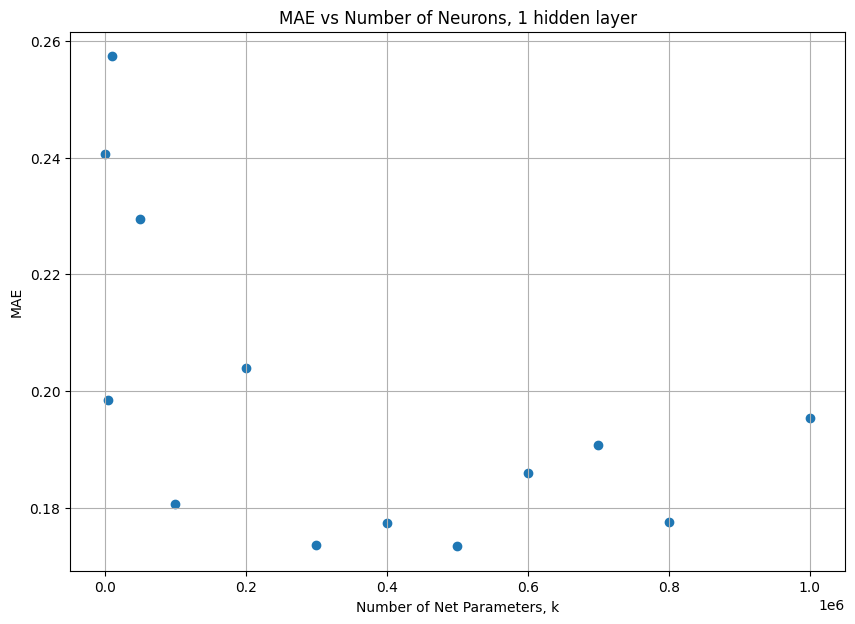

In [ ]:
num_of_neurons = [1000, 10000, 100000, 1000000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 5000, 50000, 150000]
mae_list = [0.2407, 0.2574, 0.1807, 0.1953, 0.2040, 0.1736, 0.1774, 0.1734, 0.1860, 0.1908, 0.1775, 0.1985,  0.2295]
#mse_list = [0.2110, 0.2104, 0.1872, 0.2202, 0.1959, 0.1592, 0.1682, 0.1717, 0.1694, 0.2221, 0, 0.1853,  0.2027]

plt.rcParams["figure.figsize"] = (10, 7)
plt.scatter(num_of_neurons, mae_list)
plt.grid()
plt.title("MAE vs Number of Neurons, 1 hidden layer")
plt.xlabel("Number of Net Parameters, k")
plt.ylabel("MAE")

plt.show()

#The graph of 2 hidden layer net

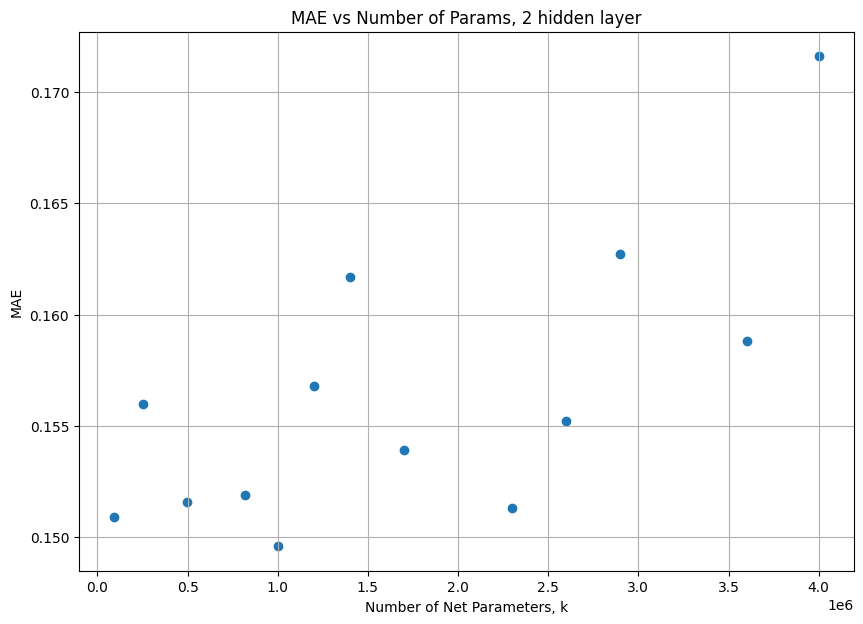

In [ ]:
num_of_params = [4000000, 2300000, 1000000, 817000, 495000, 254000, 92400, 1700000, 2600000, 2900000, 1400000, 1200000, 3600000, 4400000]
mae_list = [0.1716, 0.1513, 0.1496, 0.1519, 0.1516, 0.1560, 0.1509, 0.1539, 0.1552,  0.1627, 0.1617, 0.1568, 0.1588, ]
#mse_list = [0.1754, 0.1591, 0.1552, 0.1449, 0.1524, 0.1481, 0.1458, 0.1484, 0.1557, 0.1847, 0.1681, 0.1598, 0.1611, ]

plt.rcParams["figure.figsize"] = (10, 7)
plt.scatter(num_of_params, mae_list)
plt.grid()
plt.title("MAE vs Number of Params, 2 hidden layer")
plt.xlabel("Number of Net Parameters, k")
plt.ylabel("MAE")

plt.show()

# The graph of 3 hidden layer net

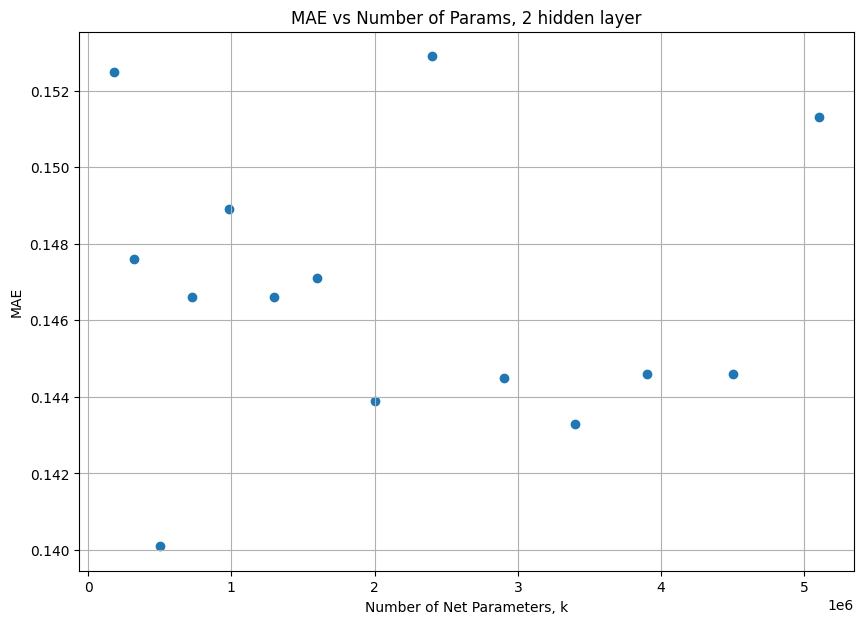

In [ ]:
num_of_params = [504000, 725000, 986000, 1300000, 1600000, 2000000, 2400000, 2900000, 3400000, 3900000, 4500000, 5100000, 323000, 182000]
mae_list = [0.1401, 0.1466, 0.1489, 0.1466, 0.1471, 0.1439, 0.1529, 0.1445, 0.1433, 0.1446, 0.1446,  0.1513, 0.1476, 0.1525]
#mse_list = [0.1375, 0.1539, -, 0.1433, 0.1499, 0.1423, 0.1583, 0.1414, 0.1426, 0.1436, 0.1455, 0.1531, 0.1579, 0.1535]

plt.rcParams["figure.figsize"] = (10, 7)
plt.scatter(num_of_params, mae_list)
plt.grid()
plt.title("MAE vs Number of Params, 2 hidden layer")
plt.xlabel("Number of Net Parameters, k")
plt.ylabel("MAE")

plt.show()

## Ebeam = 1.515, mae = 0.6842
## Ebeam = 5.754, mae =  0.0783
## Ebeam = 5.499, nae =  0.0876

# Training

In [ ]:
n_epochs = 100

loss_fn = nn.L1Loss() #params_dict.get('loss_func')
optimizer = params_dict.get('optim_func')
optimizer = optimizer(params=model.parameters(), lr=params_dict.get('lr'))
lr_optim = ReduceLROnPlateau(optimizer = optimizer,
                                     mode = 'min',
                                     factor = params_dict.get('lr_factor'),
                                     patience = params_dict.get('lr_patience'),
                                     cooldown= params_dict.get('lr_cooldown'),
                                     threshold = 0.01)

In [ ]:
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    model.train()

    train_loss_mean = 0.0
    val_loss_mean = 0.0

    for X, y in train_dataloader:
        y_preds = model(X).squeeze()
        loss = loss_fn(y_preds, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_mean += loss.item()

    train_loss_mean /= len(train_dataloader)
    train_losses.append(train_loss_mean)

    model.eval()

    with torch.inference_mode():
        for X, y in val_dataloader:
            val_preds = model(X).squeeze()
            val_loss = loss_fn(val_preds, y)

            val_loss_mean += val_loss.item()

        val_loss_mean /= len(val_dataloader)
        val_losses.append(val_loss_mean)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch + 1} | Train Loss: {train_loss_mean:.2f} | Val Loss: {val_loss_mean:.2f}')

Epoch 5 | Val Loss: 0.39 | Val Loss: 0.39
Epoch 10 | Val Loss: 0.31 | Val Loss: 0.38
Epoch 15 | Val Loss: 0.27 | Val Loss: 0.34
Epoch 20 | Val Loss: 0.25 | Val Loss: 0.22
Epoch 25 | Val Loss: 0.22 | Val Loss: 0.20
Epoch 30 | Val Loss: 0.21 | Val Loss: 0.20
Epoch 35 | Val Loss: 0.21 | Val Loss: 0.31
Epoch 40 | Val Loss: 0.20 | Val Loss: 0.19
Epoch 45 | Val Loss: 0.19 | Val Loss: 0.19
Epoch 50 | Val Loss: 0.19 | Val Loss: 0.19
Epoch 55 | Val Loss: 0.20 | Val Loss: 0.18
Epoch 60 | Val Loss: 0.19 | Val Loss: 0.19
Epoch 65 | Val Loss: 0.18 | Val Loss: 0.19
Epoch 70 | Val Loss: 0.18 | Val Loss: 0.19
Epoch 75 | Val Loss: 0.18 | Val Loss: 0.18
Epoch 80 | Val Loss: 0.18 | Val Loss: 0.19
Epoch 85 | Val Loss: 0.17 | Val Loss: 0.19
Epoch 90 | Val Loss: 0.17 | Val Loss: 0.18
Epoch 95 | Val Loss: 0.18 | Val Loss: 0.19
Epoch 100 | Val Loss: 0.17 | Val Loss: 0.17


In [ ]:
predictions = DataLoader(test_data, batch_size=len(test_data), shuffle=False)

model.eval()
with torch.inference_mode():
    for X, y in predictions:
        y_preds = model(X)
        print(f'Mean Absolute Error = {mean_absolute_error(y, y_preds)}')

Mean Absolute Error = 0.16686750429493138
